<a href="https://colab.research.google.com/github/manfredialdo/iad-tpi01/blob/main/tpi-iad01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## . Datos de identificación

- **Apellido y nombre:** manfredi aldo dario
- **Comisión:** 10
- **Dataset asignado:** hotel booking TPI grupo J.csv
- **Entrega:** Trabajo practico integrador primera entrega
- **Fecha:** 23 de agosto 2026
- **Repositorio:** https://github.com/manfredialdo/iad-tpi01

## Trabajo Práctico Integrador - Introducción al Análisis de Datos


**Cátedra:** Introducción al Análisis de Datos — UTN TUPAD

**Caso:** análisis y predicción de cancelaciones en reservas hoteleras.

**Objetivo:** Explorar las métricas de tendencia central, dispersión y frecuencias utilizando el dataset real de reservas hoteleras.
Aplicar algunos conceptos de la materia probabilidad y estadistica sobre la variable is_cancelled del dataset

**Fecha:** 23/08/2026

### 📌 Buenas Prácticas en Notebooks:
 1. **Ejecución Cronológica:** Ejecuta las celdas de arriba hacia abajo para mantener la memoria limpia.
2. **Modularización:** Una función/propósito por celda.
 3. **Narrativa + Código:** El código calcula, el texto interpreta.


## 1. Importación de librerías

In [1]:
# 1. Importación de librerías esenciales
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") # Configuración visual limpia para los gráficos
print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


##  2 - Carga del Dataset y Reconocimiento General
Antes de calcular cualquier promedio o porcentaje, la regla de oro del analista es entender la estructura básica del dataset:
* ¿Cuántos registros (filas) y variables (columnas) tenemos?
* ¿Qué tipo de variable es cada una según nuestro **Diccionario de Variables**?

In [2]:
# Carga del archivo CSV
url = "https://raw.githubusercontent.com/manfredialdo/iad-tpi01/refs/heads/main/hotel%20booking%20TPI%20grupo%20J.csv"
df = pd.read_csv(url)

In [7]:
# primer reconocimiento

# Mostrar dimensiones
filas, columnas = df.shape
print(f"El dataset contiene {filas} reservas y {columnas} variables.")
df.head(5) # Visualizar las primeras 5 filas

El dataset contiene 25000 reservas y 32 variables.


,booking_id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,arrival_date,stays_in_weekend_nights,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,HB-035978,Resort Hotel,0,261,2025,April,18,30,2025-04-30,2,...,A,0,No Deposit,40.0,NaN,0,Contract,42.95,0,1
1,HB-004892,Resort Hotel,1,85,2024,April,14,7,2024-04-07,0,...,A,0,No Deposit,67.0,NaN,0,Transient-Party,64.00,0,0
2,HB-076102,City Hotel,1,364,2023,October,42,16,2023-10-16,0,...,A,0,Non Refund,6.0,NaN,0,Transient-Party,101.50,0,0
3,HB-102752,City Hotel,0,32,2024,December,49,4,2024-12-04,2,...,D,0,No Deposit,9.0,NaN,0,Transient,114.00,0,0
4,HB-069831,City Hotel,1,126,2025,June,23,7,2025-06-07,0,...,A,0,No Deposit,27.0,NaN,0,Transient,89.10,0,1


**Presentación breve del problema**

Vamos a intentar ver porque hay tantas reservas canceladas, si obedecen a un patron..

A partir de la variable is_cancelled vamos a intentar contestar a partir de la  **Variable objetivo:** `is_canceled` la cual muestra como

- `0`: reserva no cancelada.
- `1`: reserva cancelada.




vamos a ver si la tasa de cancelacion tiene alguna relacion con el pais de origen donde se toman las reservas, el umbral de precios q maneja el dataset, y si el tipo de huesped (reincidentes) nos puede ayudar a prevenir cancelaciones futuras...


**Síntesis** Ninguna medida vive sola: Un promedio sin desvío estándar o sin comparar contra la mediana puede llevar a conclusiones erróneas...  El tipo de variable manda: Las categóricas se resumen con frecuencias; las cuantitativas con tendencia central y dispersión.



In [ ]:
# Comprobar la cantidad de filas canceladas (1) y no canceladas (0)
print("Frecuencia absoluta:")
print(df["is_canceled"].value_counts())

# Tasa porcentual de cancelación
print("\nTasa de cancelación (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

Frecuencia absoluta:
is_canceled
0    15741
1     9259
Name: count, dtype: int64

Tasa de cancelación (%):
is_canceled
0    62.964
1    37.036
Name: proportion, dtype: float64


Del total de 25000 reservas del dataset

💡el 37,03% son de **reservas canceladas** representan un total de 9259


💡el 62,96% de **reservas canceladas** representan un total de 15741


## 3. Variables Categóricas: Fr. Absolutas y Relativas
Las frecuencias organizan variables cualitativas o binarias.
Veamos qué pasa con **`is_canceled`**

($0 =$ Reserva Efectiva, $1 =$ Reserva Cancelada):
* **Frecuencia Absoluta:** Conteo puro de reservas.
* **Frecuencia Relativa:** Porcentaje respecto al total (evita engaños por volumen).

In [ ]:
# Cálculo de frecuencias para cancelaciones
frec_absoluta = df['is_canceled'].value_counts()
frec_relativa = df['is_canceled'].value_counts(normalize=True) * 100

# Crear una tabla resumen
tabla_cancelaciones = pd.DataFrame({
    'Cantidad de Reservas': frec_absoluta,
    'Porcentaje (%)': frec_relativa.round(2)
})
tabla_cancelaciones.index = ['No Cancelada (0)', 'Cancelada (1)']
print(tabla_cancelaciones)

# sns.countplot(data=df, x='is_canceled', hue='is_canceled', palette=['#2ec4b6', '#e71d36'], legend=False)


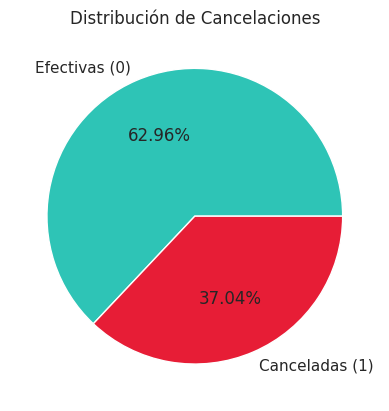




💡 mas de un tercio del total de reservas resultan ser canceladas...

In [ ]:
df['is_canceled'].value_counts().plot.pie(autopct='%1.2f%%', colors=['#2ec4b6', '#e71d36'], labels=['Efectivas (0)', 'Canceladas (1)'], title='Distribución de Cancelaciones', ylabel='')

In [ ]:
df['is_canceled'].value_counts().sort_index().plot.pie(
    autopct='%1.2f%%',
    colors=['#2ec4b6', '#e71d36'],
    labels=['Efectivas (0)', 'Canceladas (1)'],
    title='Distribución de Cancelaciones',
    ylabel='',
    figsize=(6, 6)
)


Insights clave: La proporción de reservas canceladas y los valores extremos en las tarifas son variables a estudiar.

Revela 5 puntos estratégicos sobre los datos:

Tasa de pérdida / Cancelación efectivizada: El 37.04% de las intenciones de reserva termina en cancelación, lo que representa una fuga directa de clientes potenciales antes de su llegada.

Tasa de ocupación o conversión inicial: Solo el 62.96% (15,741 reservas) se convierte en una estancia real concretada para el hotel.

Proporción de pérdidas (Relación 5 a 3): Por cada 5 reservas que se mantienen con éxito, aproximadamente 3 terminan siendo canceladas.

Equilibrio para modelos predictivos (Machine Learning): La relación de clases es ~63:37, lo que demuestra un desbalance moderado. Esto es positivo porque el modelo tiene suficientes ejemplos de ambas situaciones para aprender a predecir cancelaciones sin necesitar técnicas complejas de rebalanceo (como SMOTE).

Métrica de referencia (Baseline / Benchmark): Establece el valor promedio global contra el cual evaluarás cualquier otra variable. Si al segmentar por país, tipo de cliente o canal de venta ves tasas superiores al 37.04%, habrás identificado un segmento de alto riesgo.


### 5.1 **que humbral de precios esta manejando el dataset?**



se busca analizar el atributo adr del dataset


Medidas de Dispersión y Posición: Variabilidad y Boxplot
Para la tarifa diaria promedio (**`adr`** en USD), no alcanza con saber el promedio: necesitamos conocer la dispersión (cuán dispersos están los precios).

* **Rango:** Diferencia entre el Máximo y el Mínimo.
* **Desvío Estándar ($S$):** Promedio de alejamiento respecto a la media.
* **Cuartiles ($Q_1, Q_2, Q_3$):** Cortes en 25%, 50% y 75% de la población.

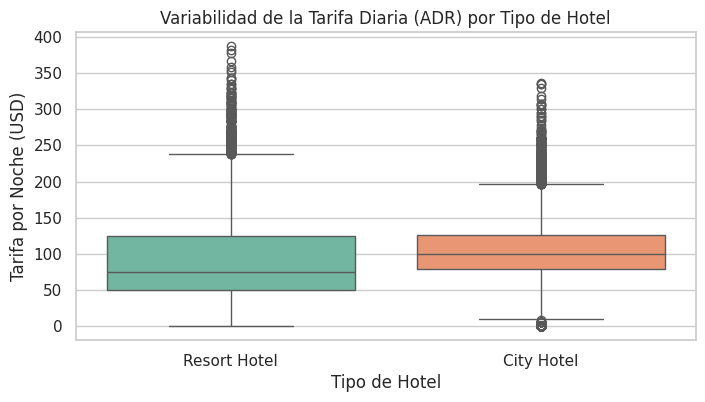




In [ ]:
# Mínimo, Máximo, Desvío Estándar y Cuartiles en un solo paso
resumen_adr = df['adr'].describe()
print(resumen_adr[['min', '25%', '50%', '75%', 'max', 'std']])

# Gráfico de Boxplot (Diagrama de Caja) por Tipo de Hotel
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='hotel', y='adr', palette='Set2')
plt.title('Variabilidad de la Tarifa Diaria (ADR) por Tipo de Hotel')
plt.xlabel('Tipo de Hotel')
plt.ylabel('Tarifa por Noche (USD)')
plt.show()

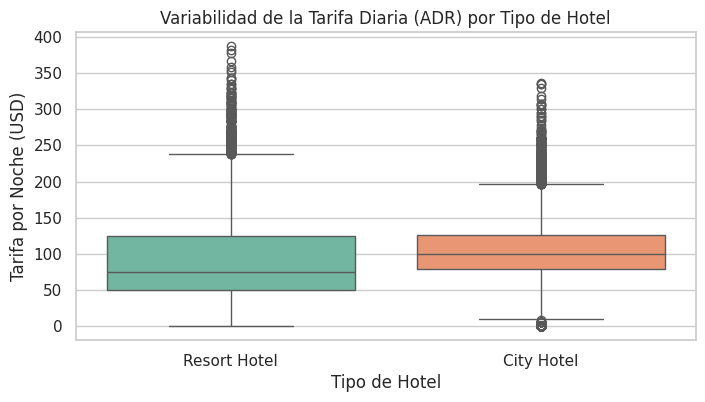

**Conclusiones visuales parcial2 del gráfico:**

Diferencias en la tarifa mediana: Se aprecia la distribución del ADR para cada categoría de hotel, permitiendo comparar visualmente sus medianas y el rango intercuartílico (IQR).

Presencia de valores atípicos (Outliers): El boxplot evidencia la existencia de valores atípicos hacia el extremo superior en el precio por noche, reflejando reservas puntuales con tarifas significativamente más elevadas que el promedio habitual de cada establecimiento.


**Interpretación de Resultados (ADR)**

Distribución central: La mitad de las tarifas cobradas se concentra entre USD 69,03 (Q1) y USD 126,00 (Q3), con un valor medio típico (mediana) de USD 94,50.

Variabilidad: La desviación estándar de USD 47,97 muestra una alta dispersión en los precios, algo habitual en hotelería debido a la temporada, tipo de habitación o demanda.

**Valores extremos:**

Mínimo (USD 0,00): Corresponde a cortesías, programas de puntos o registros incompletos.

Máximo (USD 387,00): Representa la tarifa más alta registrada en la muestra.

### 5.2 **cuantos clientes del total de reservas vuelven a efectivizar otra reserva?**



se busca analizar el atributo is_repeated_guest del dataset y volviero a efectivizar otra/s reservas al hotel...

In [ ]:
# clientes reincidentes
print(df['is_repeated_guest'].value_counts()) # cuántas reservas corresponden a clientes que ya habían visitado el hotel antes frente a los que van por primera vez.
df[df['is_repeated_guest'] != 0]['is_canceled'].value_counts() # representa: El comportamiento de cancelación exclusivo de los clientes frecuentes. Sirve para analizar si un cliente fidelizado tiene menor tendencia a cancelar que un cliente nuevo.

is_repeated_guest
0    24169
1      831
Name: count, dtype: int64


,count
is_canceled,
0,725
1,106


**conclusion parcial 3**

1. Fidelización de Clientes:

    Baja tasa de retorno: De las 25.000 reservas analizadas, solo 831 corresponden a clientes habituales (un 3,32% del total), mientras que 24.169 (96,68%) son clientes por primera vez. Esto muestra una baja tasa de fidelización en la muestra analizada.

2. Comportamiento de Cancelación en Clientes Frecuentes:

    Alta tasa de efectivización: De las 831 reservas hechas por clientes repetidos, 725 fueron concretadas (un 87,2%) y solo 106 fueron canceladas (un 12,8%).

    Mayor compromiso: Los clientes frecuentes cancelan significativamente menos que la media general. Esto confirma que un cliente fidelizado tiene un nivel de compromiso mucho más alto con la reserva y representa un ingreso mucho más seguro para el hotel.

### 5.3 **top10 cancelaciones por pais de origen**



se busca analizar el atributo is_repeated_guest del dataset y volviero a efectivizar otra/s reservas al hotel...



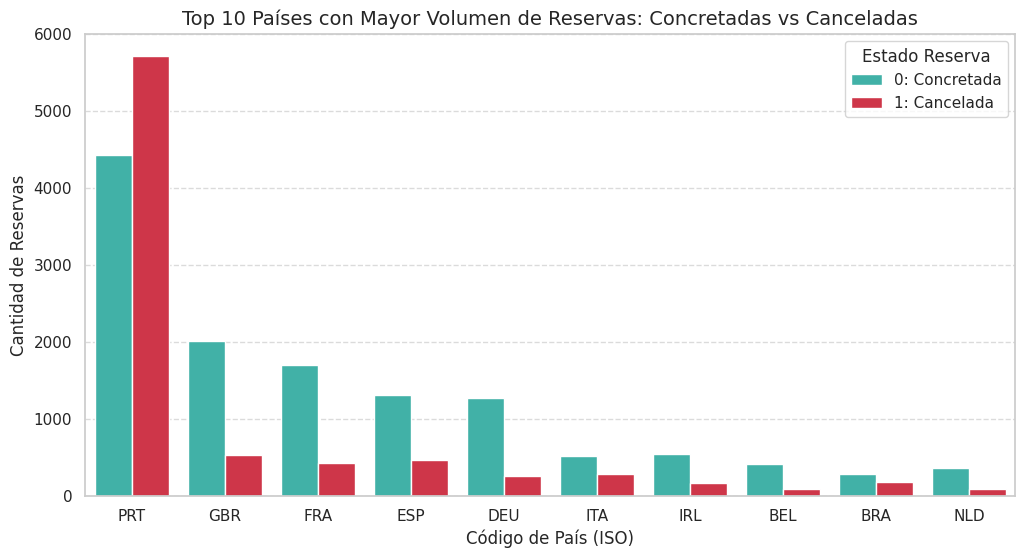

In [ ]:
# Agrupa por país y calcula el total de reservas y la tasa media de cancelación
# Agrupa por país y calcula el total de reservas y la tasa media de cancelación
top_paises = df.groupby('country')['is_canceled'].agg(Total_Reservas='count', Tasa_Cancelacion='mean', Cancelaciones_Absolutas='sum')

# Filtra solo los 10 países con más reservas para que sea representativo
top_paises.sort_values(by='Total_Reservas', ascending=False).head(10).assign(Tasa_Cancelacion=lambda x: (x['Tasa_Cancelacion'] * 100).round(2).astype(str) + '%')


,Total_Reservas,Tasa_Cancelacion,Cancelaciones_Absolutas
country,,,
PRT,10159,56.32%,5722
GBR,2544,20.95%,533
FRA,2128,19.92%,424
ESP,1775,26.54%,471
DEU,1539,17.02%,262
ITA,788,35.15%,277
IRL,704,23.44%,165
BEL,501,18.36%,92
BRA,462,38.53%,178


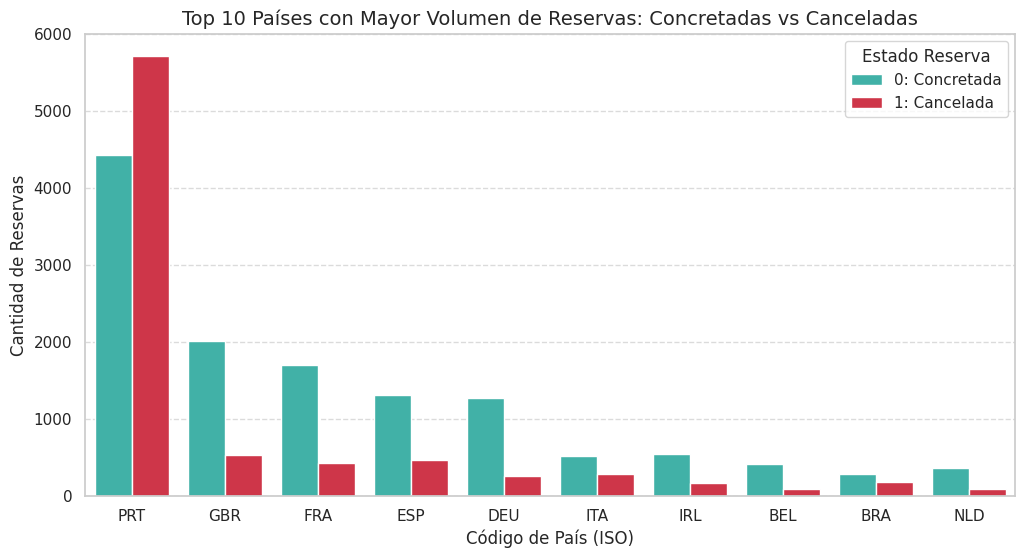

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener los 10 países con mayor volumen de reservas
top10_paises = df['country'].value_counts().head(10).index

# 2. Filtrar el DataFrame para conservar solo esos 10 países
df_top10 = df[df['country'].isin(top10_paises)]

# 3. Crear el gráfico de barras comparativo
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_top10,
    x='country',
    hue='is_canceled',
    order=top10_paises,
    palette=['#2ec4b6', '#e71d36'],
)

# 4. Personalizar títulos y etiquetas
plt.title(
    'Top 10 Países con Mayor Volumen de Reservas: Concretadas vs Canceladas',
    fontsize=14,
)
plt.xlabel('Código de País (ISO)', fontsize=12)
plt.ylabel('Cantidad de Reservas', fontsize=12)
plt.legend(
    title='Estado Reserva',
    labels=['0: Concretada', '1: Cancelada'],
    frameon=True,
)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


**Cancelaciones por País de Origen (Top 10)**

Concentración del mercado: Portugal (PRT) es con diferencia el principal mercado emisor (10.159 reservas, más del 40% del total), seguido por el Reino Unido (GBR), Francia (FRA) y España (ESP).

Riesgo crítico en el mercado local: Portugal no solo lidera en volumen, sino también en cancelaciones, alcanzando una tasa atípicamente alta del 56,32% (5.722 cancelaciones).

**Comportamiento por regiones:**

Mercado internacional estable: Países del centro y norte de Europa como Alemania (17,02%), Bélgica (18,36%), Francia (19,92%) y Holanda (20,52%) registran los menores niveles de cancelación.

Mercado de mayor volatilidad: Brasil (38,53%) e Italia (35,15%) presentan altas tasas de cancelación dentro de los clientes internacionales.

Conclusión: La mayoría de las cancelaciones están concentradas en el público local (Portugal). Una política de depósitos previa o condiciones de cancelación más estrictas para el mercado nacional impactaría directamente en la reducción de cancelaciones globales.

## 6. Conclusiones parciales

El análisis descriptivo y de frecuencias del dataset de reservas hoteleras (compuesto por 25.000 registros) permite extraer las siguientes conclusiones estratégicas para la toma de decisiones:

**Tasa de cancelación y línea de base:** El 37.04% de las intenciones de reserva termina en cancelación (9.260 casos), lo que significa que el hotel experimenta una fuga directa de clientes potenciales antes de su llegada. El restante 62.96% (15.741 reservas) se convierte en estancias efectivas. Esta tasa general del 37.04% constituye el benchmark de referencia global contra el cual se medirá el rendimiento de cualquier otro segmento o variable del negocio.


**Comportamiento y variabilidad de la tarifa diaria (ADR):** Las tarifas muestran una alta dispersión debido a la naturaleza dinámica del mercado hotelero, con una desviación estándar de USD 47.97. Mientras que el valor medio típico (mediana) se sitúa en USD 94.50, la mitad de las tarifas cobradas oscila en un rango central de USD 69.03 (Q1) a USD 126.00 (Q3). Se detectaron valores extremos que van desde USD 0.00 (asociados a cortesías o registros incompletos) hasta una tarifa máxima de USD 387.00 con presencia de valores atípicos (outliers) en el extremo superior.


**La fidelización como mitigador de riesgo:** Se observa una bajísima tasa de retorno en el hotel; únicamente 831 reservas corresponden a clientes frecuentes. No obstante, este segmento demuestra un compromiso sobresaliente: el 87.2% de sus reservas se concreta de manera efectiva y solo el 12.8% se cancela, una tasa drásticamente inferior a la media general del 37.04%.


**Concentración y riesgo geográfico:** Portugal (PRT) representa el principal emisor de demanda del hotel, acumulando 10.159 reservas (más del 40% del volumen total). Sin embargo, representa también el mayor foco de vulnerabilidad operativa, registrando una tasa de cancelación del 56.32% (5.722 cancelaciones). En contraste, los mercados de Europa central y del norte (como Alemania y Francia) exhiben una notable estabilidad, con tasas de cancelación inferiores al 20%

## 7. Limitaciones y próximos pasos


**Falta de análisis temporal:** El comportamiento dinámico de las tarifas (ADR) y las cancelaciones aún no ha sido cruzado con variables de tiempo (estacionalidad, meses de alta demanda o anticipación de la reserva).


**Aislamiento de variables:** Todavía no se ha estudiado en profundidad la correlación o el impacto simultáneo del ADR, tipo de hotel (Resort o de Ciudad) o canal de distribución sobre la probabilidad de cancelación.

Próximos pasos recomendados:

**Estrategias de mitigación comercial:** Proponer al hotel la implementación de políticas de depósitos previos o cobros por cancelación anticipada enfocadas específicamente en el mercado local (Portugal) para frenar la alta tasa de cancelaciones sin desincentivar la demanda estable. Asimismo, estructurar programas de fidelización debido a la alta probabilidad de concreción que tienen los clientes recurrentes.


**Preparación para Modelado de Machine Learning (Predictivo):** La distribución observada de cancelaciones vs. reservas efectivas (~63% frente a ~37%) revela un desbalance moderado, lo cual es sumamente positivo. Permite planificar el entrenamiento de modelos de clasificación predictiva sin la necesidad de recurrir a técnicas artificiales complejas de rebalanceo (como SMOTE).


**Ingeniería de variables y entrenamiento:** El siguiente hito técnico será realizar ingeniería de características (Feature Engineering) para incorporar de forma estructurada variables cualitativas y numéricas a un modelo que prediga is_canceled, utilizando el 37.04% establecido como baseline para evaluar la precisión del modelo clasificador